## 0 · Install / verify dependencies
Run this cell once if any package is missing.

In [8]:
# Uncomment and run if packages are not yet installed
# !pip install folium geopandas contextily matplotlib shapely pillow requests
%pip install contextily

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 1 · Well Metadata & GeoJSON Construction

In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║       CELL 1B — METHOD 2: INTERACTIVE GUI FORM (ipywidgets)         ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
# Run this cell to open the styled input form.
# EITHER paste raw NLOG text into the top box and click "Parse Text",
# OR fill in the fields manually.
# Then click "✓ Apply to WELL_DATA" — run the map cell afterwards.

import re
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Dark petroleum-industry stylesheet ────────────────────────────────
display(HTML("""<style>
.wf-wrap   { background:#0b1520; border:1px solid #1c3a5e; padding:18px;
             font-family:'Courier New',monospace; border-radius:6px; }
.wf-head   { color:#7ec8e3; font-size:14px; font-weight:bold;
             letter-spacing:3px; text-transform:uppercase;
             border-bottom:1px solid #1c3a5e; padding-bottom:8px;
             margin-bottom:14px; }
.wf-sect   { color:#4a9eca; font-size:10px; font-weight:bold;
             letter-spacing:2px; text-transform:uppercase;
             background:#0f2035; border-left:3px solid #1f77b4;
             padding:5px 10px; margin:14px 0 6px 0; }
.widget-label          { color:#9ab !important; font-size:11px !important;
                         font-family:'Courier New',monospace !important;
                         min-width:195px !important; }
.widget-text input,
.widget-float-text input,
.widget-textarea textarea {
  background:#0f1e30 !important; color:#dde8f0 !important;
  border:1px solid #1c4a72 !important; border-radius:3px !important;
  font-family:'Courier New',monospace !important; font-size:11px !important; }
.widget-text input:focus,
.widget-float-text input:focus,
.widget-textarea textarea:focus {
  border-color:#1f77b4 !important; box-shadow:0 0 6px #1f77b430 !important; }
.wf-parse button { background:#163a5a !important; color:#7ec8e3 !important;
  border:1px solid #1f77b4 !important; padding:6px 18px !important;
  font-family:'Courier New',monospace !important; font-size:11px !important;
  border-radius:3px !important; cursor:pointer !important; }
.wf-apply button { background:#1f77b4 !important; color:#fff !important;
  border:none !important; padding:9px 32px !important;
  font-family:'Courier New',monospace !important; font-size:12px !important;
  font-weight:bold !important; letter-spacing:1px !important;
  border-radius:4px !important; cursor:pointer !important; margin-top:12px !important; }
.wf-ok  { background:#0b2218; color:#66bb6a; border:1px solid #2e7d32;
           padding:7px 12px; border-radius:3px; font-size:11px;
           font-family:'Courier New',monospace; margin-top:8px; }
.wf-err { background:#220f0f; color:#ef9a9a; border:1px solid #b71c1c;
           padding:7px 12px; border-radius:3px; font-size:11px;
           font-family:'Courier New',monospace; margin-top:8px; }
</style>"""))

# ── Field terminators for inline parser ───────────────────────────────
_STOP = (
    r'Identificatie:|Locatie:|Aangeleverde locatie:|Opdrachtgever:|'
    r'Begindatum boring:|Einddatum boring:|Type boring:|Status:|'
    r'Resultaat van de boring:|Einddiepte:|Verticale positie|Vorm boortraject:|'
    r'Werkelijke verticale diepte:|Deviatie de x-richting:|Deviatie de y-richting:|'
    r'Platform/mijnbouwwerk:|Boorfirma:|Link naar|$'
)
def _f(key, text):
    m = re.search(rf'(?:{key})\s*:\s*(.*?)(?={_STOP})', text, re.I | re.S)
    return m.group(1).strip() if m else ""

def _parse(text):
    d = {}
    m = re.search(r'(?:Boring|Well)\s+([\w\-\/]+)', text, re.I)
    if m: d["well_name"] = m.group(1).strip()
    m = re.search(r'(?:Locatie|Location)\s*:\s*([\d]+\.[\d]+)\s*,\s*([\d]+\.[\d]+)\s*\(WGS84\)', text, re.I)
    if m:
        a, b = float(m.group(1)), float(m.group(2))
        d["latitude_wgs84"], d["longitude_wgs84"] = (a,b) if a>b else (b,a)
    d["operator"]              = _f(r'Opdrachtgever|Operator', text)
    d["startdate_drilling"]    = _f(r'Begindatum boring|Start date', text)
    d["enddate_drilling"]      = _f(r'Einddatum boring|End date', text)
    d["status"]                = _f(r'Status', text)
    d["platform_installation"] = _f(r'Platform/mijnbouwwerk|Platform', text)
    raw_type = _f(r'Type boring|Well type', text)
    _tm = {"Exploratie koolwaterstof":"Exploration hydrocarbon","Productie":"Production",
           "Injectie":"Injection","Ontwikkeling":"Development hydrocarbon"}
    d["well_type"]   = next((v for k,v in _tm.items() if k.lower() in raw_type.lower()), raw_type)
    raw_res = _f(r'Resultaat van de boring|Result', text)
    _rm = {"Droog":"Dry","Olie":"Oil","Gas":"Gas","Olie en gas":"Oil & Gas"}
    d["well_result"] = next((v for k,v in _rm.items() if k.lower() in raw_res.lower()), raw_res)
    def _n(pat): m=re.search(pat,text,re.I); return float(m.group(1)) if m else 0.0
    d["end_depth_m_rkb"] = _n(r'Einddiepte\s*:\s*([\d\.]+)\s*m')
    d["tvd_m_rkb"]       = _n(r'Werkelijke verticale diepte\s*:\s*([\d\.]+)\s*m')
    d["deviation_x_m"]   = _n(r'Deviatie de x-richting\s*:\s*([+-]?[\d\.]+)\s*m')
    d["deviation_y_m"]   = _n(r'Deviatie de y-richting\s*:\s*([+-]?[\d\.]+)\s*m')
    m = re.search(r'(https?://www\.nlog\.nl[^\s]+)', text, re.I)
    if m: d["nlog_url"] = m.group(1).strip()
    return d

# ── Widget helpers ────────────────────────────────────────────────────
W = widgets.Layout
def tw(lbl, val="", ph=""):
    return widgets.Text(value=str(val), placeholder=ph, description=lbl,
        style={"description_width":"195px"}, layout=W(width="680px"))
def fw(lbl, val=0.0):
    return widgets.FloatText(value=val, description=lbl,
        style={"description_width":"195px"}, layout=W(width="400px"))

# ── Input widgets ─────────────────────────────────────────────────────
w_paste = widgets.Textarea(value="", layout=W(width="680px", height="80px"),
    placeholder="Paste raw NLOG text here → click 'Parse Text' to auto-fill all fields below ↓")
w_name  = tw("Well Name *",           ph="e.g. Q13-A-05-SIDETRACK1")
w_lat   = fw("Latitude WGS84 °N *")
w_lon   = fw("Longitude WGS84 °E *")
w_dx    = fw("Deviation X m  (E+/W−)")
w_dy    = fw("Deviation Y m  (N+/S−)")
w_op    = tw("Operator",              ph="e.g. Shell Netherlands B.V.")
w_field = tw("Field Code",            ph="e.g. Q13a-Amstel (Q13-FA)")
w_type  = tw("Well Type",             ph="e.g. Development hydrocarbon")
w_stat  = tw("Status",                ph="e.g. Producing/Injecting")
w_res   = tw("Result",                ph="e.g. Oil / Gas / Dry")
w_start = tw("Start Date Drilling",   ph="DD-MM-YYYY")
w_end   = tw("End Date Drilling",     ph="DD-MM-YYYY")
w_dep   = fw("End Depth  m RKB")
w_tvd   = fw("TVD  m RKB")
w_plat  = tw("Platform/Installation", ph="e.g. Ensco 70")
w_url   = tw("NLOG URL",             ph="https://www.nlog.nl/...")

# ── Buttons & output ──────────────────────────────────────────────────
btn_parse = widgets.Button(description="⟳  Parse Text",
    layout=W(width="160px", margin="4px 10px 0 0"))
btn_parse.add_class("wf-parse")
btn_apply = widgets.Button(description="✓  Apply to WELL_DATA",
    layout=W(width="220px"))
btn_apply.add_class("wf-apply")
out = widgets.Output()

def on_parse(b):
    out.clear_output()
    p = _parse(w_paste.value)
    if not p:
        with out: display(HTML('<div class="wf-err">⚠  No fields found in pasted text.</div>'))
        return
    fill = {w_name:"well_name", w_lat:"latitude_wgs84", w_lon:"longitude_wgs84",
            w_dx:"deviation_x_m", w_dy:"deviation_y_m", w_op:"operator",
            w_type:"well_type", w_stat:"status", w_res:"well_result",
            w_start:"startdate_drilling", w_end:"enddate_drilling",
            w_dep:"end_depth_m_rkb", w_tvd:"tvd_m_rkb",
            w_plat:"platform_installation", w_url:"nlog_url"}
    for widget, key in fill.items():
        if key in p and p[key] not in ("", 0.0, 0):
            widget.value = p[key]
    with out:
        display(HTML(f'<div class="wf-ok">✓  Parsed {len(p)} fields — '
                     f'review above then click Apply.</div>'))

def on_apply(b):
    global WELL_DATA
    out.clear_output()
    if not w_name.value.strip():
        with out: display(HTML('<div class="wf-err">⚠  Well Name is required.</div>')); return
    if w_lat.value == 0.0 or w_lon.value == 0.0:
        with out: display(HTML('<div class="wf-err">⚠  Latitude and Longitude cannot be zero.</div>')); return
    WELL_DATA = {
        "well_name":              w_name.value.strip(),
        "latitude_wgs84":         w_lat.value,
        "longitude_wgs84":        w_lon.value,
        "deviation_x_m":          w_dx.value,
        "deviation_y_m":          w_dy.value,
        "operator":               w_op.value.strip(),
        "field_code":             w_field.value.strip() or w_name.value.strip(),
        "well_type":              w_type.value.strip(),
        "status":                 w_stat.value.strip(),
        "well_result":            w_res.value.strip(),
        "startdate_drilling":     w_start.value.strip(),
        "enddate_drilling":       w_end.value.strip(),
        "end_depth_m_rkb":        w_dep.value,
        "tvd_m_rkb":              w_tvd.value,
        "platform_installation":  w_plat.value.strip(),
        "nlog_url":               w_url.value.strip(),
    }
    with out:
        display(HTML(f'<div class="wf-ok">✓ WELL_DATA set for '
                     f'<b>{WELL_DATA["well_name"]}</b> — run the map cell now.</div>'))

btn_parse.on_click(on_parse)
btn_apply.on_click(on_apply)

# ── Assemble form ─────────────────────────────────────────────────────
def sect(t): return widgets.HTML(f'<div class="wf-sect">{t}</div>')

form = widgets.VBox([
    widgets.HTML('<div class="wf-head">⛽ Well Data Input — Form</div>'),
    sect("① Paste Raw NLOG Text  (optional — auto-fills everything below)"),
    w_paste, btn_parse,
    sect("② Identification"),
    w_name,
    sect("③ Location (WGS84)"),
    w_lat, w_lon, w_dx, w_dy,
    sect("④ Operator & Classification"),
    w_op, w_field, w_type, w_stat, w_res,
    sect("⑤ Drilling Dates"),
    w_start, w_end,
    sect("⑥ Depths"),
    w_dep, w_tvd,
    sect("⑦ Platform & Reference"),
    w_plat, w_url,
    widgets.HBox([btn_apply]),
    out,
], layout=W(padding="0px"))

display(widgets.HTML('<div class="wf-wrap">'), form, widgets.HTML('</div>'))
WELL_DATA = {}   # populated when Apply is clicked

HTML(value='<div class="wf-wrap">')

HTML(value='</div>')

In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║     CELL 1A — METHOD 1: PASTE RAW NLOG TEXT (Dutch or English)      ║
# ╚══════════════════════════════════════════════════════════════════════╝

import re

RAW_TEXT = """
Boring ZUIDWIJK-01
Identificatie:	ZWK-01
Locatie:	52.53363705 , 4.87231943 (WGS84)
Aangeleverde locatie:	120063.65, 505233.84 (RD)
Opdrachtgever:	Taqa Energy B.V.
Begindatum boring:	29-02-2012
Einddatum boring:	06-04-2012
Type boring:	Exploratie koolwaterstof
Status:	Ingesloten
Resultaat van de boring:	Gas
Einddiepte:	3300.000 m t.o.v. Rotary Table
Verticale positie van Rotary Table :	5.57 m t.o.v. NAP
Vorm boortraject:	Gedevieerd
Werkelijke verticale diepte:	3138.20 m t.o.v. Rotary Table
3132.63 m t.o.v. NAP
Deviatie de x-richting:	92.49 m
Deviatie de y-richting:	-840.77 m
Platform/mijnbouwwerk:	T-45
Boorfirma:	KCA Deutag Drilling Ltd
Link naar deze pagina:https://www.nlog.nl/nlog-mapviewer/brh/981353086?lang=nl
"""

# ── Field boundary keywords — lookahead terminators ───────────────────
_STOP = (
    r'Identificatie:|Locatie:|Aangeleverde locatie:|Opdrachtgever:|'
    r'Begindatum boring:|Einddatum boring:|Type boring:|Status:|'
    r'Resultaat van de boring:|Einddiepte:|Verticale positie|Vorm boortraject:|'
    r'Werkelijke verticale diepte:|Deviatie de x-richting:|Deviatie de y-richting:|'
    r'Platform/mijnbouwwerk:|Boorfirma:|Link naar|'
    r'Operator:|Start date:|End date:|Well type:|Result:|End depth:|'
    r'True vertical depth:|Deviation|Platform:|$'
)

def _field(key_pattern, text):
    m = re.search(rf'(?:{key_pattern})\s*:[\t ]*(.*?)(?={_STOP})',
                  text, re.I | re.S)
    return m.group(1).strip() if m else ""


def parse_nlog_text(text):
    d = {}

    # ── Well name ─────────────────────────────────────────────────────
    m = re.search(r'(?:Boring|Well)\s+([\w\-\/\.]+)', text, re.I)
    d["well_name"] = m.group(1).strip() if m else "UNKNOWN"

    # ── Identification (same as well name if not separately listed) ───
    raw_id = _field(r'Identificatie|Identification', text)
    d["identification"] = raw_id if raw_id else d["well_name"]

    # ── WGS84 coordinates ─────────────────────────────────────────────
    m = re.search(
        r'(?:Locatie|Location)\s*:[\t ]*([\d]+\.[\d]+)\s*,\s*([\d]+\.[\d]+)\s*\(WGS84\)',
        text, re.I)
    if m:
        a, b = float(m.group(1)), float(m.group(2))
        d["latitude_wgs84"], d["longitude_wgs84"] = (a, b) if a > b else (b, a)
    else:
        d["latitude_wgs84"] = d["longitude_wgs84"] = 0.0

    # ── Text fields ───────────────────────────────────────────────────
    d["operator"]              = _field(r'Opdrachtgever|Operator',          text)
    d["startdate_drilling"]    = _field(r'Begindatum boring|Start date',    text)
    d["enddate_drilling"]      = _field(r'Einddatum boring|End date',       text)
    d["status"]                = _field(r'Status',                          text)
    d["platform_installation"] = _field(r'Platform/mijnbouwwerk|Platform',  text)
    d["drilling_company"]      = _field(r'Boorfirma|Drilling company',      text)

    # Trajectory — translate Dutch → English
    raw_traj = _field(r'Vorm boortraject|Trajectory', text)
    _traj = {"Verticaal": "Vertical", "Gedevieerd": "Deviated",
             "Horizontaal": "Horizontal", "Multilateral": "Multilateral"}
    d["trajectory"] = next(
        (v for k, v in _traj.items() if k.lower() in raw_traj.lower()), raw_traj)

    # Well type — translate Dutch → English
    raw_type = _field(r'Type boring|Well type', text)
    _types = {
        "Exploratie koolwaterstof" : "Exploration hydrocarbon",
        "Productie"                : "Production",
        "Injectie"                 : "Injection",
        "Appraisal"                : "Appraisal",
        "Ontwikkeling"             : "Development hydrocarbon",
    }
    d["well_type"] = next(
        (v for k, v in _types.items() if k.lower() in raw_type.lower()), raw_type)

    # Result — translate Dutch → English
    raw_result = _field(r'Resultaat van de boring|Result', text)
    _results = {
        "Droog"      : "Dry",
        "Olie shows" : "Oil shows",
        "Olie en gas": "Oil & Gas",
        "Olie"       : "Oil",
        "Gas"        : "Gas",
    }
    d["well_result"] = next(
        (v for k, v in _results.items() if k.lower() in raw_result.lower()),
        raw_result)

    # ── Numeric fields ────────────────────────────────────────────────
    def _num(pat, default=0.0):
        m = re.search(pat, text, re.I)
        return float(m.group(1)) if m else default

    d["end_depth_m_rkb"] = _num(r'Einddiepte\s*:[\t ]*([\d\.]+)\s*m')
    d["tvd_m_rkb"]       = _num(r'Werkelijke verticale diepte\s*:[\t ]*([\d\.]+)\s*m')
    d["deviation_x_m"]   = _num(r'Deviatie de x-richting\s*:[\t ]*([+-]?[\d\.]+)\s*m')
    d["deviation_y_m"]   = _num(r'Deviatie de y-richting\s*:[\t ]*([+-]?[\d\.]+)\s*m')

    # TVD relative to MSL — second number on the TVD line or after newline
    # Pattern: "3436.47 m t.o.v. Rotary Table\n3402.37 m t.o.v. MSL"
    m = re.search(
        r'Werkelijke verticale diepte\s*:[\t ]*[\d\.]+\s*m[^\n]*\n\s*([\d\.]+)\s*m',
        text, re.I)
    if m:
        d["tvd_m_msl"] = float(m.group(1))
    else:
        # fallback: tvd_rkb minus KB elevation if available
        m_kb = re.search(r'Verticale positie[^\:]*:\s*([\d\.]+)\s*m', text, re.I)
        kb = float(m_kb.group(1)) if m_kb else 0.0
        d["tvd_m_msl"] = round(d["tvd_m_rkb"] - kb, 2) if kb else d["tvd_m_rkb"]

    # ── URL & field code ──────────────────────────────────────────────
    m = re.search(r'(https?://www\.nlog\.nl[^\s]+)', text, re.I)
    d["nlog_url"]   = m.group(1).strip() if m else ""
    d["field_code"] = d["well_name"]

    return d


# ── Run parser ────────────────────────────────────────────────────────
if RAW_TEXT.strip():
    WELL_DATA = parse_nlog_text(RAW_TEXT)
    print("✅  Parsed from raw text:")
    for k, v in WELL_DATA.items():
        print(f"   {k:<28} = {v}")
else:
    print("ℹ️   RAW_TEXT is empty — use the GUI cell (Method 2).")
    WELL_DATA = {}

✅  Parsed from raw text:
   well_name                    = ZUIDWIJK-01
   identification               = ZWK-01
   latitude_wgs84               = 52.53363705
   longitude_wgs84              = 4.87231943
   operator                     = Taqa Energy B.V.
   startdate_drilling           = 29-02-2012
   enddate_drilling             = 06-04-2012
   status                       = Ingesloten
   platform_installation        = T-45
   drilling_company             = KCA Deutag Drilling Ltd
   trajectory                   = Deviated
   well_type                    = Exploration hydrocarbon
   well_result                  = Gas
   end_depth_m_rkb              = 3300.0
   tvd_m_rkb                    = 3138.2
   deviation_x_m                = 92.49
   deviation_y_m                = -840.77
   tvd_m_msl                    = 3132.63
   nlog_url                     = https://www.nlog.nl/nlog-mapviewer/brh/981353086?lang=nl
   field_code                   = ZUIDWIJK-01


In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FILE PATHS + GeoJSON BUILDER  —  run this immediately after parser ║
# ╚══════════════════════════════════════════════════════════════════════╝
import json, os, math

# ── Output file paths — auto-named from well name ─────────────────────
_safe          = WELL_DATA["well_name"].replace("/", "-").replace(" ", "_")
GEOJSON_FILE   = f"{_safe}.geojson"
HTML_MAP_FILE  = f"{_safe}_map.html"
MAP_IMAGE_FILE = f"{_safe}_map.png"

print(f"  GEOJSON_FILE   = {GEOJSON_FILE}")
print(f"  HTML_MAP_FILE  = {HTML_MAP_FILE}")
print(f"  MAP_IMAGE_FILE = {MAP_IMAGE_FILE}")

# ── Bottom-hole WGS84 position ────────────────────────────────────────
_lat    = WELL_DATA["latitude_wgs84"]
_lon    = WELL_DATA["longitude_wgs84"]
_dx     = WELL_DATA.get("deviation_x_m", 0.0)
_dy     = WELL_DATA.get("deviation_y_m", 0.0)
_lat_bh = _lat + _dy / 111_000
_lon_bh = _lon + _dx / (111_000 * math.cos(math.radians(_lat)))

# ── Build GeoJSON ──────────────────────────────────────────────────────
geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [_lon, _lat]},
            "properties": {
                "location_type"        : "Surface (Wellhead)",
                "well_name"            : WELL_DATA.get("well_name", ""),
                "identification"       : WELL_DATA.get("identification", ""),
                "latitude_wgs84"       : _lat,
                "longitude_wgs84"      : _lon,
                "operator"             : WELL_DATA.get("operator", ""),
                "field_code"           : WELL_DATA.get("field_code", ""),
                "well_type"            : WELL_DATA.get("well_type", ""),
                "trajectory"           : WELL_DATA.get("trajectory", ""),
                "status"               : WELL_DATA.get("status", ""),
                "well_result"          : WELL_DATA.get("well_result", ""),
                "startdate_drilling"   : WELL_DATA.get("startdate_drilling", ""),
                "enddate_drilling"     : WELL_DATA.get("enddate_drilling", ""),
                "end_depth_m_rkb"      : WELL_DATA.get("end_depth_m_rkb", 0.0),
                "tvd_m_rkb"            : WELL_DATA.get("tvd_m_rkb", 0.0),
                "tvd_m_msl"            : WELL_DATA.get("tvd_m_msl", 0.0),
                "deviation_x_m"        : _dx,
                "deviation_y_m"        : _dy,
                "platform_installation": WELL_DATA.get("platform_installation", ""),
                "drilling_company"     : WELL_DATA.get("drilling_company", ""),
                "nlog_url"             : WELL_DATA.get("nlog_url", ""),
            }
        },
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [_lon_bh, _lat_bh]},
            "properties": {
                "location_type"   : "Bottom-hole",
                "well_name"       : WELL_DATA.get("well_name", ""),
                "latitude_wgs84"  : _lat_bh,
                "longitude_wgs84" : _lon_bh,
                "deviation_x_m"   : _dx,
                "deviation_y_m"   : _dy,
                "tvd_m_rkb"       : WELL_DATA.get("tvd_m_rkb", 0.0),
                "tvd_m_msl"       : WELL_DATA.get("tvd_m_msl", 0.0),
            }
        },
        {
            "type": "Feature",
            "geometry": {
                "type": "LineString",
                "coordinates": [[_lon, _lat], [_lon_bh, _lat_bh]]
            },
            "properties": {
                "location_type": "Trajectory (horizontal projection)",
                "well_name"    : WELL_DATA.get("well_name", ""),
                "deviation_x_m": _dx,
                "deviation_y_m": _dy,
            }
        }
    ]
}

with open(GEOJSON_FILE, "w") as f:
    json.dump(geojson, f, indent=2)

print(f"\n✅  GeoJSON saved → {GEOJSON_FILE}")
print(f"   Surface     : {_lat:.6f} N, {_lon:.6f} E")
print(f"   Bottom-hole : {_lat_bh:.6f} N, {_lon_bh:.6f} E")
print(f"   Features    : {len(geojson['features'])}  (surface point, BH point, trajectory line)")


  GEOJSON_FILE   = ZUIDWIJK-01.geojson
  HTML_MAP_FILE  = ZUIDWIJK-01_map.html
  MAP_IMAGE_FILE = ZUIDWIJK-01_map.png

✅  GeoJSON saved → ZUIDWIJK-01.geojson
   Surface     : 52.533637 N, 4.872319 E
   Bottom-hole : 52.526063 N, 4.873689 E
   Features    : 3  (surface point, BH point, trajectory line)


## 2 · Preview GeoJSON

In [4]:
import geopandas as gpd

gdf = gpd.read_file(GEOJSON_FILE)
print(f"CRS : {gdf.crs}")
print(f"Shape : {gdf.shape}")
gdf.T   # transpose for easier reading of a single-row table

CRS : EPSG:4326
Shape : (3, 22)


,0,1,2
location_type,Surface (Wellhead),Bottom-hole,Trajectory (horizontal projection)
well_name,ZUIDWIJK-01,ZUIDWIJK-01,ZUIDWIJK-01
identification,ZWK-01,None,None
latitude_wgs84,52.533637,52.526063,NaN
longitude_wgs84,4.872319,4.873689,NaN
operator,Taqa Energy B.V.,None,None
field_code,ZUIDWIJK-01,None,None
well_type,Exploration hydrocarbon,None,None
trajectory,Deviated,None,None
status,Ingesloten,None,None


## 3 · Interactive Map (Folium)
Renders inline in the notebook **and** saves a standalone HTML file.

In [5]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                CELL 2 — INTERACTIVE FOLIUM MAP                      ║
# ╚══════════════════════════════════════════════════════════════════════╝

import folium
import math
from folium import plugins

LAT = WELL_DATA["latitude_wgs84"]
LON = WELL_DATA["longitude_wgs84"]

# ── Safe getter — never crashes on missing keys ───────────────────────
def g(key, fallback="—"):
    return WELL_DATA.get(key, fallback)

# ── Base map ──────────────────────────────────────────────────────────
m = folium.Map(location=[LAT, LON], zoom_start=10,
               tiles="OpenStreetMap")   # ← default tile

# ── Tile layers ───────────────────────────────────────────────────────
folium.TileLayer("CartoDB positron",   name="Light (CartoDB)",  control=True).add_to(m)
folium.TileLayer("Esri.WorldImagery",  name="Satellite (ESRI)", control=True).add_to(m)
folium.TileLayer("CartoDB dark_matter",name="Dark (CartoDB)",   control=True).add_to(m)

# ── Popup HTML ────────────────────────────────────────────────────────
def row(label, value, shade=False):
    bg = "background:#e8f0fe;" if shade else ""
    return (f'<tr style="{bg}"><td style="padding:4px 8px;white-space:nowrap;">'
            f'<b>{label}</b></td>'
            f'<td style="padding:4px 8px;">{value}</td></tr>')

popup_html = f"""
<div style="font-family:'Segoe UI',sans-serif;width:320px;font-size:13px;">
  <div style="background:#1a3a5c;color:white;padding:8px 12px;
              border-radius:6px 6px 0 0;">
    <b style="font-size:15px;">🛢 {g('well_name')}</b>
  </div>
  <table style="width:100%;border-collapse:collapse;background:#f9f9f9;">
    {row("Identification",  g("identification"),          False)}
    {row("Operator",        g("operator"),                True)}
    {row("Well Type",       g("well_type"),               False)}
    {row("Trajectory",      g("trajectory"),              True)}
    {row("Status",          g("status"),                  False)}
    {row("Result",          g("well_result"),             True)}
    {row("Start Drilling",  g("startdate_drilling"),      False)}
    {row("End Drilling",    g("enddate_drilling"),        True)}
    {row("End Depth (RKB)", f"{g('end_depth_m_rkb')} m", False)}
    {row("TVD (RKB)",       f"{g('tvd_m_rkb')} m",       True)}
    {row("TVD (MSL)",       f"{g('tvd_m_msl', '—')} m",  False)}
    {row("ΔX / ΔY",         f"{g('deviation_x_m')} m / {g('deviation_y_m')} m", True)}
    {row("Platform",        g("platform_installation"),   False)}
    {row("Drilling Co.",    g("drilling_company"),        True)}
    {row("Field",           g("field_code"),              False)}
    {row("Coordinates",     f"{LAT:.6f} N, {LON:.6f} E", True)}
  </table>
  <div style="background:#1a3a5c;padding:6px 12px;
              border-radius:0 0 6px 6px;text-align:center;">
    <a href="{g('nlog_url','#')}" target="_blank"
       style="color:#90caf9;font-size:12px;">🔗 View on NLOG</a>
  </div>
</div>
"""

popup = folium.Popup(
    folium.IFrame(popup_html, width=340, height=460), max_width=360)

# ── Surface well marker ───────────────────────────────────────────────
folium.CircleMarker(
    location=[LAT, LON],
    radius=10,
    color="#FF4500", fill=True, fill_color="#FF6B35",
    fill_opacity=0.85, weight=2,
    popup=popup,
    tooltip=folium.Tooltip(
        f"<b>{g('well_name')}</b><br>"
        f"🛢 {g('well_result')} | {g('status')}<br>"
        f"{LAT:.5f} N, {LON:.5f} E",
        sticky=True
    )
).add_to(m)

# ── Well name label ───────────────────────────────────────────────────
folium.Marker(
    location=[LAT + 0.008, LON],
    icon=folium.DivIcon(
        html=f"""<div style="background:rgba(26,58,92,0.88);color:white;
                     padding:3px 8px;border-radius:4px;
                     font-family:'Segoe UI',sans-serif;font-size:11px;
                     font-weight:bold;white-space:nowrap;
                     border:1px solid #FF4500;">
                  {g('well_name')}</div>""",
        icon_size=(200, 28), icon_anchor=(100, 28)
    )
).add_to(m)

# ── Bottom-hole marker & deviation line ───────────────────────────────
lat_bh = LAT + g("deviation_y_m", 0) / 111_000
lon_bh = LON + g("deviation_x_m", 0) / (111_000 * math.cos(math.radians(LAT)))

folium.CircleMarker(
    location=[lat_bh, lon_bh],
    radius=6,
    color="#FFC107", fill=True, fill_color="#FFD54F",
    fill_opacity=0.8, weight=2,
    tooltip=folium.Tooltip(
        f"<b>Bottom-hole location</b><br>"
        f"ΔX = {g('deviation_x_m')} m<br>"
        f"ΔY = {g('deviation_y_m')} m<br>"
        f"TVD = {g('tvd_m_rkb')} m (RKB)",
        sticky=True
    )
).add_to(m)

folium.PolyLine(
    locations=[[LAT, LON], [lat_bh, lon_bh]],
    color="#FFC107", weight=2,
    dash_array="6 4",
    tooltip="Well deviation (surface → bottom-hole)"
).add_to(m)

# ── GeoJSON overlay ───────────────────────────────────────────────────
folium.GeoJson(
    GEOJSON_FILE,
    name="GeoJSON layer",
    marker=folium.CircleMarker(
        radius=4, fill_color="white", fill_opacity=0.0,
        color="white", weight=0),
    show=False
).add_to(m)

# ── Controls ──────────────────────────────────────────────────────────
plugins.MeasureControl(
    position="bottomleft", primary_length_unit="kilometers").add_to(m)
folium.LayerControl(position="topright", collapsed=False).add_to(m)
plugins.MiniMap(toggle_display=True, position="bottomright").add_to(m)
plugins.Fullscreen(position="topleft").add_to(m)

# ── Save & display ────────────────────────────────────────────────────
m.save(HTML_MAP_FILE)
print(f"✅  Interactive HTML map saved → {HTML_MAP_FILE}")
m

/Users/apple/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✅  Interactive HTML map saved → ZUIDWIJK-01_map.html


## 4 · Static Map Image (PNG)
Uses **contextily** for basemap tiles and **geopandas** / **matplotlib** for rendering.

Surface    : 52.533637 °N,  4.872319 °E
Bottom-hole: 52.526063 °N,  4.873689 °E


/var/folders/7x/n43ldjyn17n1mx3b563hl8r00000gn/T/ipykernel_11663/3644502880.py:172: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


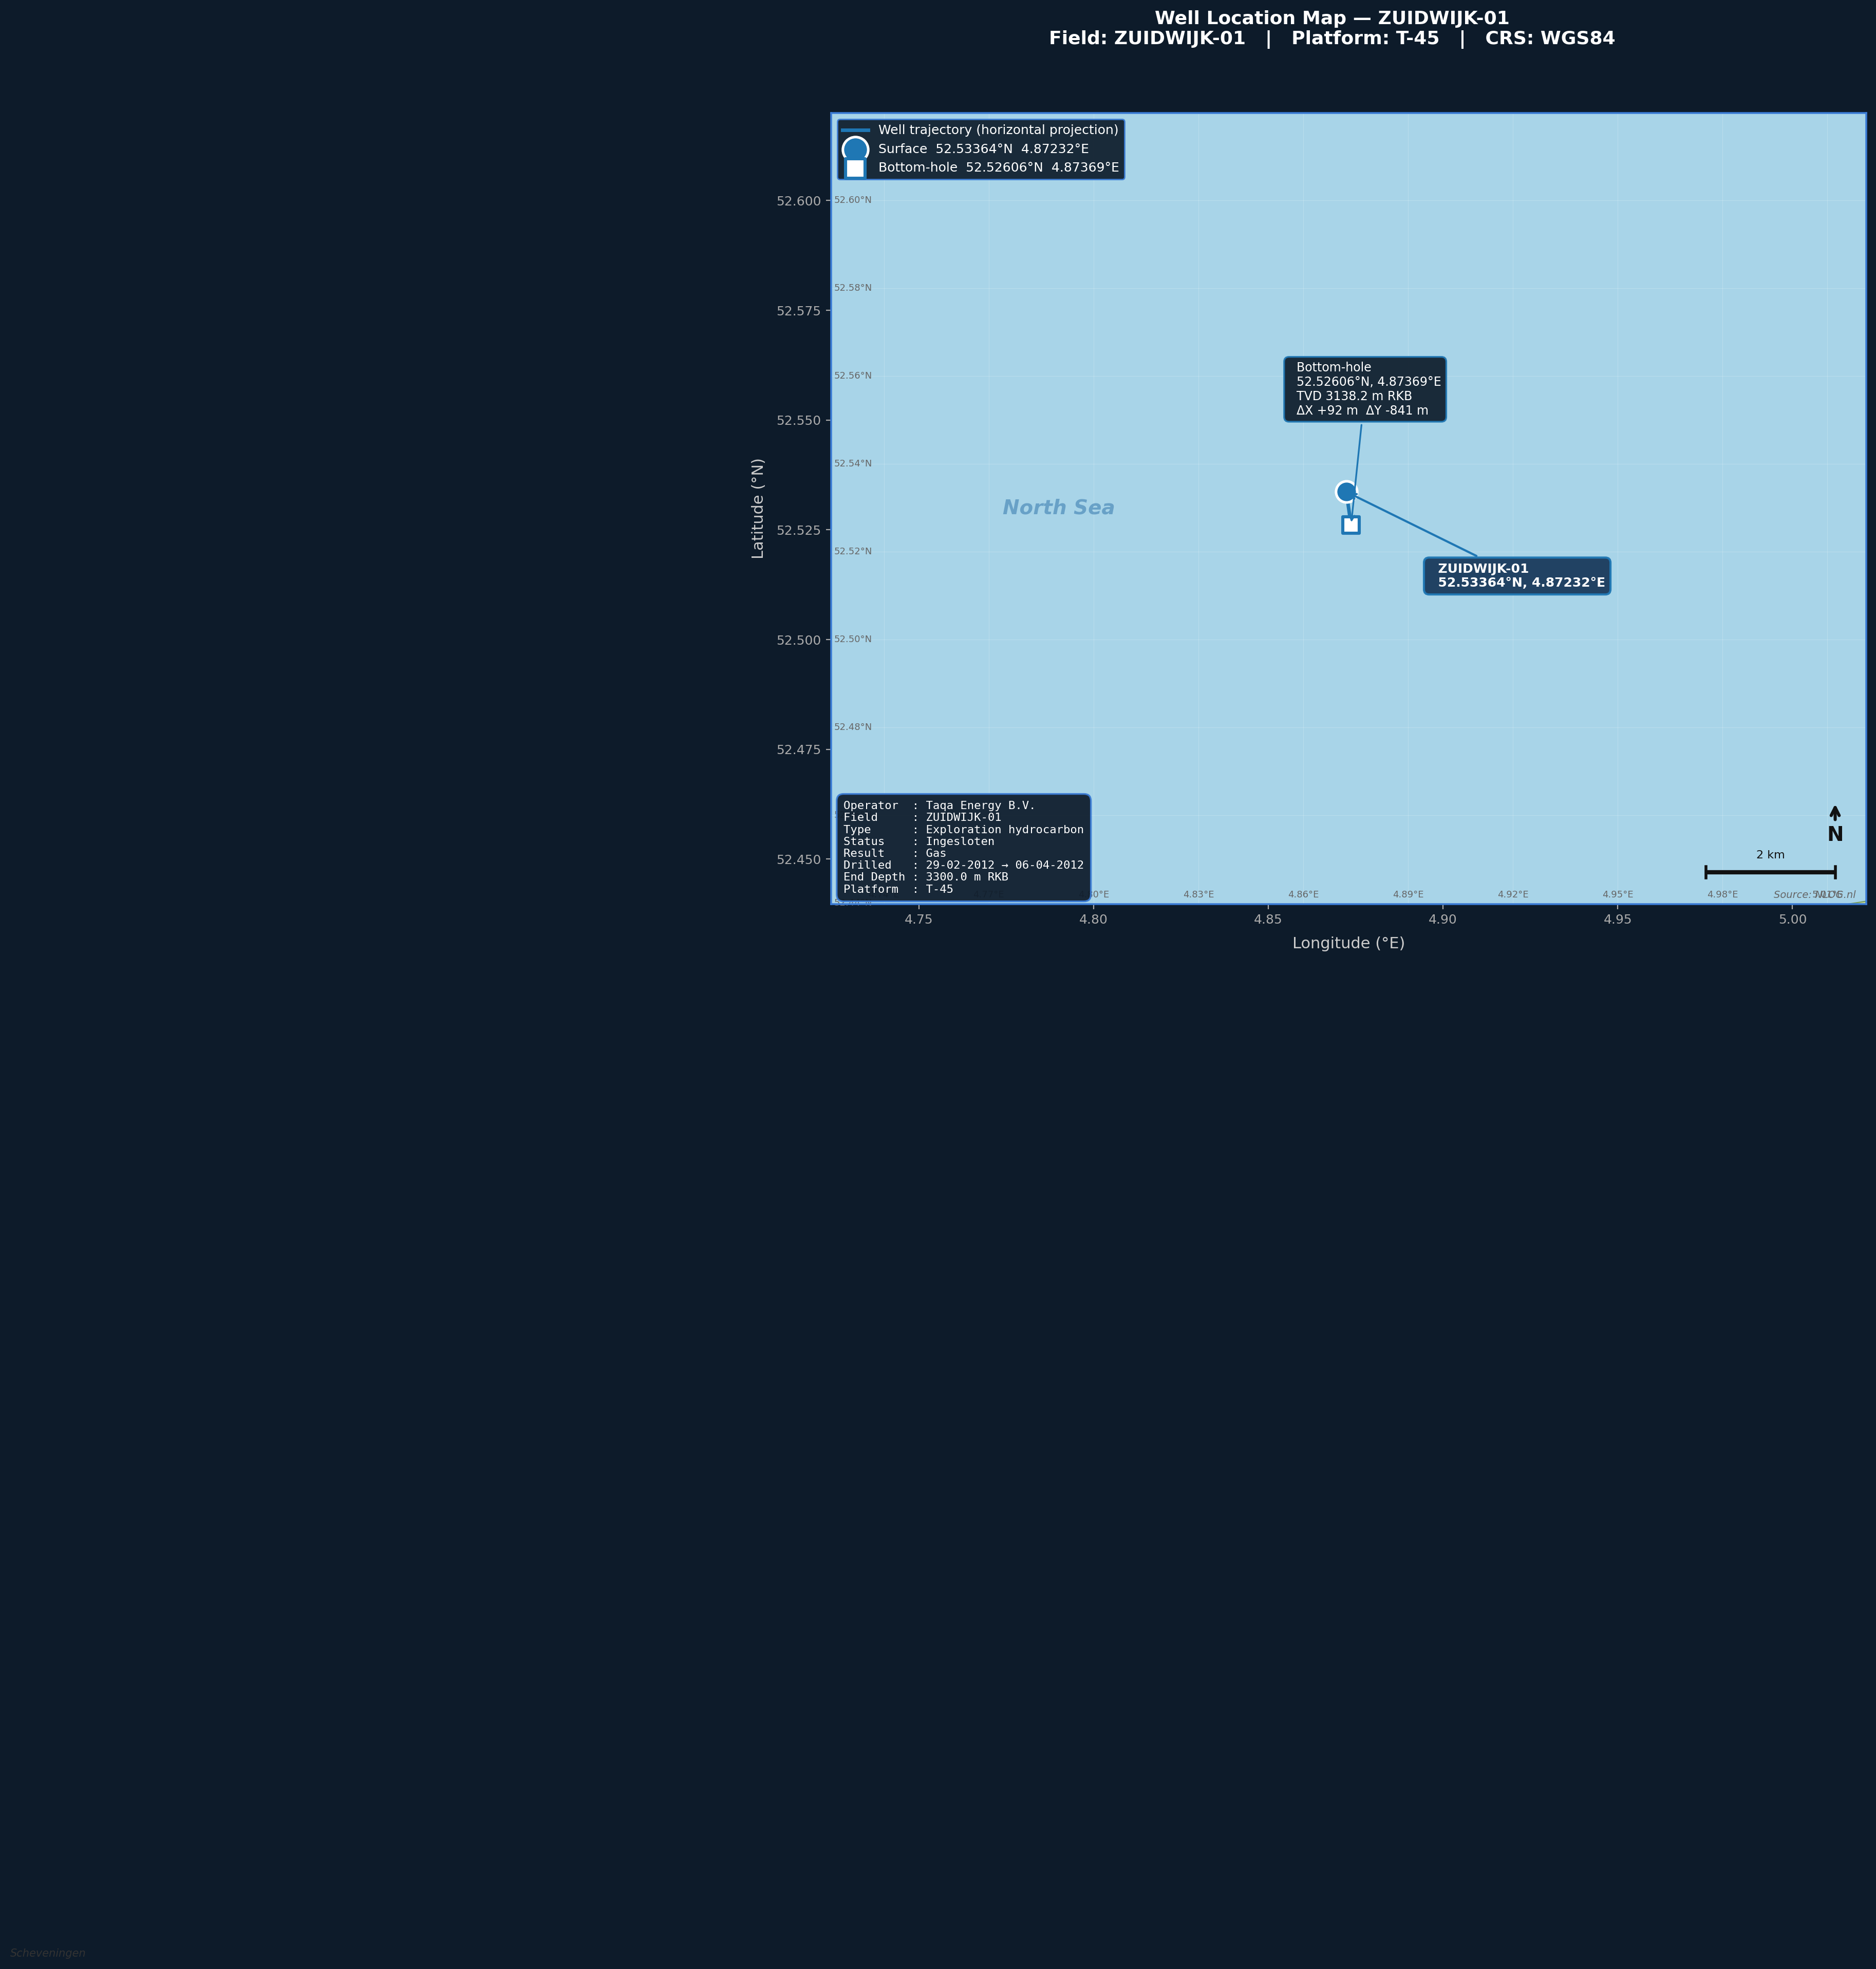

✅  Saved → ZUIDWIJK-01_map.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import math

# ── Coordinates from WELL_DATA ────────────────────────────────────────
LAT   = WELL_DATA["latitude_wgs84"]
LON   = WELL_DATA["longitude_wgs84"]
dev_x = WELL_DATA["deviation_x_m"]
dev_y = WELL_DATA["deviation_y_m"]

lat_bh = LAT + dev_y / 111_000
lon_bh = LON + dev_x / (111_000 * math.cos(math.radians(LAT)))

print(f"Surface    : {LAT:.6f} °N,  {LON:.6f} °E")
print(f"Bottom-hole: {lat_bh:.6f} °N,  {lon_bh:.6f} °E")

# ── 8 km extent centred on midpoint of the two points ─────────────────
mid_lat = (LAT + lat_bh) / 2
mid_lon = (LON + lon_bh) / 2




#resolution scale
km = 10.0



deg_lat = km / 111.0
deg_lon = km / (111.0 * math.cos(math.radians(LAT)))

lat_min = mid_lat - deg_lat;  lat_max = mid_lat + deg_lat
lon_min = mid_lon - deg_lon;  lon_max = mid_lon + deg_lon
lat_span = lat_max - lat_min; lon_span = lon_max - lon_min

well_name = WELL_DATA["well_name"]

# ── Figure ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10), dpi=200, facecolor="#0d1b2a")
ax.set_facecolor("#a8d4e8")
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# ── Real Dutch coastline — GPS-verified WGS84 vertices ────────────────
nl_coast = np.array([
    [4.123, 51.975],[4.125, 52.000],[4.128, 52.020],[4.132, 52.040],
    [4.138, 52.060],[4.158, 52.075],[4.190, 52.088],[4.228, 52.100],
    [4.272, 52.110],[4.325, 52.118],[4.372, 52.125],[4.418, 52.136],
    [4.448, 52.153],[4.465, 52.172],[4.478, 52.198],[4.492, 52.222],
    [4.507, 52.252],[4.513, 52.280],[4.522, 52.308],[4.532, 52.335],
    [4.543, 52.358],[4.552, 52.382],
])

land_lon = list(nl_coast[:, 0]) + [5.5, 7.0, 7.0, 4.5, 4.2, 4.123]
land_lat = list(nl_coast[:, 1]) + [52.5, 52.5, 51.8, 51.8, 51.95, 51.975]
ax.fill(land_lon, land_lat, color="#c5d9a0", zorder=2, ec="#7a9e5a", lw=0.8)

beach_inner = nl_coast.copy(); beach_inner[:, 0] += 0.012
beach_lon = list(nl_coast[:, 0]) + list(beach_inner[::-1, 0])
beach_lat = list(nl_coast[:, 1]) + list(beach_inner[::-1, 1])
ax.fill(beach_lon, beach_lat, color="#e8d58a", zorder=3, alpha=0.85)
ax.plot(nl_coast[:, 0], nl_coast[:, 1], color="#6a8c4a", lw=1.0, zorder=4)

# Coastal labels (only drawn if within view)
if lon_max > 4.47:
    ax.text(4.490, 52.200, "Scheveningen", fontsize=7.5, color="#333333",
            ha="left", zorder=5, style="italic")
if lon_max > 4.16 and lat_min < 52.07:
    ax.text(4.155, 52.065, "Hook of Holland", fontsize=7, color="#333333",
            ha="left", zorder=5, style="italic")

# North Sea label
ax.text(lon_min + lon_span*0.22, mid_lat, "North Sea",
        fontsize=14, color="#2a6fa8", ha="center", va="center",
        style="italic", fontweight="bold", alpha=0.50, zorder=3)

# ── Graticule ─────────────────────────────────────────────────────────
for glon in np.arange(round(lon_min/0.03)*0.03, lon_max+0.03, 0.03):
    if lon_min <= glon <= lon_max:
        ax.axvline(glon, color="white", lw=0.25, alpha=0.3, zorder=1)
        ax.text(glon, lat_min+lat_span*0.006, f"{glon:.2f}°E",
                fontsize=6.5, color="#666666", ha="center", va="bottom", zorder=2)
for glat in np.arange(round(lat_min/0.02)*0.02, lat_max+0.02, 0.02):
    if lat_min <= glat <= lat_max:
        ax.axhline(glat, color="white", lw=0.25, alpha=0.3, zorder=1)
        ax.text(lon_min+lon_span*0.003, glat, f"{glat:.2f}°N",
                fontsize=6.5, color="#666666", ha="left", va="center", zorder=2)

# ── Trajectory — solid blue ───────────────────────────────────────────
ax.plot([LON, lon_bh], [LAT, lat_bh], color="#1f77b4", lw=2.5, ls="-",
        zorder=6, label="Well trajectory (horizontal projection)")

ax.scatter(LON, LAT, s=220, color="#1f77b4", zorder=8,
           edgecolors="white", linewidths=1.8, marker="o",
           label=f"Surface  {LAT:.5f}°N  {LON:.5f}°E")

ax.scatter(lon_bh, lat_bh, s=130, color="white", zorder=8,
           edgecolors="#1f77b4", linewidths=2.2, marker="s",
           label=f"Bottom-hole  {lat_bh:.5f}°N  {lon_bh:.5f}°E")

ax.annotate(f"  {well_name}\n  {LAT:.5f}°N, {LON:.5f}°E",
    xy=(LON, LAT), xytext=(LON+lon_span*0.08, LAT-lat_span*0.12),
    fontsize=9, fontweight="bold", color="white",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a3a5c",
              edgecolor="#1f77b4", lw=1.5, alpha=0.95),
    arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1.5), zorder=9)

ax.annotate(f"  Bottom-hole\n  {lat_bh:.5f}°N, {lon_bh:.5f}°E\n"
            f"  TVD {WELL_DATA['tvd_m_rkb']} m RKB\n"
            f"  ΔX {dev_x:+.0f} m  ΔY {dev_y:+.0f} m",
    xy=(lon_bh, lat_bh), xytext=(lon_bh-lon_span*0.06, lat_bh+lat_span*0.14),
    fontsize=8.5, color="white",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#0d1b2a",
              edgecolor="#1f77b4", lw=1.2, alpha=0.92),
    arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1.2), zorder=9)

# ── Info box — bottom left ────────────────────────────────────────────
info_text = (
    f"Operator  : {WELL_DATA['operator']}\n"
    f"Field     : {WELL_DATA['field_code']}\n"
    f"Type      : {WELL_DATA['well_type']}\n"
    f"Status    : {WELL_DATA['status']}\n"
    f"Result    : {WELL_DATA['well_result']}\n"
    f"Drilled   : {WELL_DATA['startdate_drilling']} → {WELL_DATA['enddate_drilling']}\n"
    f"End Depth : {WELL_DATA['end_depth_m_rkb']} m RKB\n"
    f"Platform  : {WELL_DATA['platform_installation']}"
)
ax.text(0.012, 0.012, info_text, transform=ax.transAxes,
        fontsize=8, va="bottom", fontfamily="monospace", color="white",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#0d1b2a",
                  edgecolor="#3a7bd5", lw=1.2, alpha=0.93), zorder=10)

# ── North arrow — bottom right ────────────────────────────────────────
ax.annotate("N", xy=(0.97, 0.13), xytext=(0.97, 0.08),
            xycoords="axes fraction", textcoords="axes fraction",
            fontsize=14, fontweight="bold", color="#111111", ha="center",
            arrowprops=dict(arrowstyle="->", color="#111111", lw=2.2))

# ── Scale bar — bottom right ──────────────────────────────────────────
bar_km = round(km / 4, 1)  



bar_deg = bar_km / (111.0 * math.cos(math.radians(LAT)))
bx1 = lon_max - lon_span*0.03; bx0 = bx1 - bar_deg
by  = lat_min + lat_span*0.04; th  = lat_span*0.007
ax.plot([bx0,bx1],[by,by], color="#111111", lw=3, solid_capstyle="butt", zorder=10)
ax.plot([bx0,bx0],[by-th,by+th], color="#111111", lw=2, zorder=10)
ax.plot([bx1,bx1],[by-th,by+th], color="#111111", lw=2, zorder=10)
bar_label = f"{bar_km:.0f} km" if bar_km == int(bar_km) else f"{bar_km:.1f} km"
ax.text((bx0+bx1)/2, by+th*2.2, f"{bar_km:.0f} km",
        fontsize=8, color="#111111", ha="center", va="bottom", zorder=10)

ax.text(0.99, 0.005, "Source: NLOG.nl", transform=ax.transAxes,
        fontsize=7, color="#666666", ha="right", va="bottom", style="italic")

ax.set_xlabel("Longitude (°E)", fontsize=11, color="#cccccc", labelpad=7)
ax.set_ylabel("Latitude (°N)",  fontsize=11, color="#cccccc", labelpad=7)
ax.tick_params(colors="#aaaaaa", labelsize=9)
for s in ax.spines.values():
    s.set_edgecolor("#3a7bd5"); s.set_linewidth(1.3)
ax.legend(loc="upper left", framealpha=0.92, facecolor="#0d1b2a",
          edgecolor="#3a7bd5", labelcolor="white", fontsize=9, markerscale=1.2)

fig.suptitle(
    f"Well Location Map — {well_name}\n"
    f"Field: {WELL_DATA['field_code']}   |   "
    f"Platform: {WELL_DATA['platform_installation']}   |   CRS: WGS84",
    fontsize=13, fontweight="bold", color="white", y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(MAP_IMAGE_FILE, dpi=200, bbox_inches="tight", facecolor="#0d1b2a")
plt.show()
print(f"✅  Saved → {MAP_IMAGE_FILE}")

## 5 · Summary of Saved Files

In [7]:
import os

files = [
    ("GeoJSON", GEOJSON_FILE),
    #("Interactive map",   HTML_MAP_FILE),
    ("Static map (PNG)",  MAP_IMAGE_FILE),
]

print("=" * 65)
print(f"  Output summary — {WELL_DATA['well_name']}")
print("=" * 65)
for label, path in files:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1024 if exists else 0
    status = f"✅  {size:7.1f} kB" if exists else "❌  NOT FOUND"
    print(f"  {label:<20}  {status}")
    print(f"    → {path}")
    print()
print("=" * 65)

  Output summary — ZUIDWIJK-01
  GeoJSON               ✅      2.0 kB
    → ZUIDWIJK-01.geojson

  Static map (PNG)      ✅    255.8 kB
    → ZUIDWIJK-01_map.png

